## Für ML optimierten Datensatz laden und mit Tankstellendaten mergen

In [4]:
import pandas as pd
import gc
import ctypes

def ram_freigeben():
    gc.collect()
    ctypes.CDLL("libc.so.6").malloc_trim(0)

# =========================================
# TEIL 1: Laden
# =========================================

# ML-Daten laden
df = pd.read_parquet("../data/ml/ml_master_dataset.parquet")

# Stationsdaten laden (nur 30 Zeilen)
stationen = (
    pd.read_parquet(
        "../data/ml/analysis_dataset.parquet",
        columns=["station_uuid", "latitude", "longitude", "distanz_km", "brand", "post_code"]
    )
    .drop_duplicates(subset="station_uuid")
    .copy()
)
stationen["brand"] = stationen["brand"].str.strip()
stationen = pd.get_dummies(stationen, columns=["brand"], prefix="brand", dtype=int)

print(df.shape)
display(df.head())

(7292538, 27)


,date,station_uuid,kraftstoff,preis,jahr,quartal,monat,tag,stunde,wochentag,...,brent_usd,eur_usd,co2_preis_eur_t,energiesteuer_benzin,energiesteuer_diesel,ist_tankrabatt,ist_lockdown,ist_niedrigwasser,ist_schulferien_nrw,ist_feiertag_nrw
0,2014-06-08 09:50:01,005056ba-7cb6-1ed2-bceb-88651ca7cd30,diesel,1.339,2014,2,6,8,9,6,...,109.989998,1.3608,0.0,65.449997,47.040001,False,False,False,False,False
1,2014-06-08 09:50:01,51d4b453-a095-1aa0-e100-80009459e03a,e5,1.529,2014,2,6,8,9,6,...,109.989998,1.3608,0.0,65.449997,47.040001,False,False,False,False,False
2,2014-06-08 17:02:01,7e2d0df2-59cc-4fb1-896f-0a6a090236b6,e10,1.619,2014,2,6,8,17,6,...,109.989998,1.3608,0.0,65.449997,47.040001,False,False,False,False,False
3,2014-06-08 09:50:01,7e2d0df2-59cc-4fb1-896f-0a6a090236b6,e10,1.539,2014,2,6,8,9,6,...,109.989998,1.3608,0.0,65.449997,47.040001,False,False,False,False,False
4,2014-06-08 09:50:01,0d04596e-aa4b-44d9-9059-f55beddb0e0b,diesel,1.319,2014,2,6,8,9,6,...,109.989998,1.3608,0.0,65.449997,47.040001,False,False,False,False,False


## Preise im Wide-Format speichern

In [5]:
# =========================================
# TEIL 2: Pivot → Wide Format
# =========================================

from joblib import Parallel, delayed
import numpy as np

chunks = np.array_split(df, 19)

def pivot_chunk(chunk):
    return chunk.pivot(
        index=["date", "station_uuid",
               "jahr", "quartal", "monat", "tag", "stunde",
               "wochentag", "ist_wochenende", "date_day",
               "temp_avg", "temp_min", "temp_max", "niederschlag_mm", "sonnenstunden",
               "brent_usd", "eur_usd", "co2_preis_eur_t",
               "energiesteuer_benzin", "energiesteuer_diesel", "ist_tankrabatt",
               "ist_lockdown", "ist_niedrigwasser", "ist_schulferien_nrw", "ist_feiertag_nrw"],
        columns="kraftstoff",
        values="preis"
    ).reset_index()

results = Parallel(n_jobs=19)(delayed(pivot_chunk)(chunk) for chunk in chunks)

df_wide = pd.concat(results, ignore_index=True)
df_wide.columns.name = None
df_wide = df_wide.rename(columns={
    "diesel": "preis_diesel",
    "e5":     "preis_e5",
    "e10":    "preis_e10"
})

# Preise e5, e10 droppen
df_wide = df_wide.drop(columns=["preis_e5", "preis_e10"])

del df, results, chunks
ram_freigeben()

# Bool-Spalten in int casten
bool_spalten = [
    "ist_wochenende", "ist_tankrabatt", "ist_lockdown",
    "ist_niedrigwasser", "ist_schulferien_nrw", "ist_feiertag_nrw"
]
df_wide[bool_spalten] = df_wide[bool_spalten].astype(int)

print(df_wide.shape)
display(df_wide.head())



/home/rex/anaconda3/lib/python3.12/site-packages/numpy/core/fromnumeric.py:59: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


(2437958, 26)


,date,station_uuid,jahr,quartal,monat,tag,stunde,wochentag,ist_wochenende,date_day,...,eur_usd,co2_preis_eur_t,energiesteuer_benzin,energiesteuer_diesel,ist_tankrabatt,ist_lockdown,ist_niedrigwasser,ist_schulferien_nrw,ist_feiertag_nrw,preis_diesel
0,2014-06-08 09:50:01,005056ba-7cb6-1ed2-bceb-88651ca7cd30,2014,2,6,8,9,6,1,2014-06-08,...,1.3608,0.0,65.449997,47.040001,0,0,0,0,0,1.339
1,2014-06-08 09:50:01,005056ba-7cb6-1ed2-bceb-a51b92434d41,2014,2,6,8,9,6,1,2014-06-08,...,1.3608,0.0,65.449997,47.040001,0,0,0,0,0,1.319
2,2014-06-08 09:50:01,0d04596e-aa4b-44d9-9059-f55beddb0e0b,2014,2,6,8,9,6,1,2014-06-08,...,1.3608,0.0,65.449997,47.040001,0,0,0,0,0,1.319
3,2014-06-08 09:50:01,1ca575b3-0473-46e5-bbeb-7542fdc9a381,2014,2,6,8,9,6,1,2014-06-08,...,1.3608,0.0,65.449997,47.040001,0,0,0,0,0,1.329
4,2014-06-08 09:50:01,1d79a70e-806c-4eaa-8d8f-5075cff9e67e,2014,2,6,8,9,6,1,2014-06-08,...,1.3608,0.0,65.449997,47.040001,0,0,0,0,0,1.359


In [6]:
# =========================================
# TEIL 3: Merge mit Stationsdaten
# =========================================

stationen = (
    pd.read_parquet(
        "../data/ml/analysis_dataset.parquet",
        columns=["station_uuid", "latitude", "longitude", "distanz_km", "brand", "post_code"]
    )
    .drop_duplicates(subset="station_uuid")
    .copy()
)
stationen["brand"] = stationen["brand"].str.strip()
stationen = pd.get_dummies(stationen, columns=["brand"], prefix="brand", dtype=int)

df_wide = df_wide.merge(stationen, on="station_uuid", how="left")
del stationen
ram_freigeben()

print(df_wide.shape)
display(df_wide.head())

(2437958, 43)


,date,station_uuid,jahr,quartal,monat,tag,stunde,wochentag,ist_wochenende,date_day,...,brand_ESSO,brand_Globus SB Warenhaus,brand_JET,brand_Markant,brand_REWE,brand_SB,brand_STAR,brand_Shell,brand_Tankstelle Lietsch,brand_Westfalen Tankstelle
0,2014-06-08 09:50:01,005056ba-7cb6-1ed2-bceb-88651ca7cd30,2014,2,6,8,9,6,1,2014-06-08,...,0,0,0,0,0,0,1,0,0,0
1,2014-06-08 09:50:01,005056ba-7cb6-1ed2-bceb-a51b92434d41,2014,2,6,8,9,6,1,2014-06-08,...,0,0,0,0,0,0,1,0,0,0
2,2014-06-08 09:50:01,0d04596e-aa4b-44d9-9059-f55beddb0e0b,2014,2,6,8,9,6,1,2014-06-08,...,0,0,0,0,0,0,0,0,0,0
3,2014-06-08 09:50:01,1ca575b3-0473-46e5-bbeb-7542fdc9a381,2014,2,6,8,9,6,1,2014-06-08,...,0,0,0,0,0,1,0,0,0,0
4,2014-06-08 09:50:01,1d79a70e-806c-4eaa-8d8f-5075cff9e67e,2014,2,6,8,9,6,1,2014-06-08,...,0,0,0,1,0,0,0,0,0,0


## Lücken in der Zeitreihe prüfen + interpolieren

In [7]:
# =========================================
# TEIL 3a: Lücken in der Zeitreihe prüfen + interpolieren
# =========================================

# Summen NaN je Spalte printen
print(df_wide.isnull().sum())
print(f"\nGesamt NaN: {df_wide.isnull().sum().sum()}")

# Wo liegen die NaN zeitlich?
nan_diesel = df_wide[df_wide["preis_diesel"].isna()]

print(f"Zeitraum: {nan_diesel['date'].min()} bis {nan_diesel['date'].max()}")
print(f"\nNaN pro Jahr:")
print(nan_diesel["jahr"].value_counts().sort_index())
print(f"\nNaN pro Station:")
print(nan_diesel["station_uuid"].value_counts())

# Pro Station: sind die NaN isoliert oder in Blöcken?
for station in df_wide["station_uuid"].unique():
    station_df = df_wide[df_wide["station_uuid"] == station].sort_values("date")
    nan_mask = station_df["preis_diesel"].isna()
    
    if nan_mask.sum() == 0:
        continue
    
    # Aufeinanderfolgende NaN-Blöcke zählen
    bloecke = (nan_mask != nan_mask.shift()).cumsum()[nan_mask].value_counts()
    max_block = bloecke.max() if len(bloecke) > 0 else 0
    
    print(f"{station[:8]}... | NaN: {nan_mask.sum():4d} | max. Block: {max_block}")

date                                       0
station_uuid                               0
jahr                                       0
quartal                                    0
monat                                      0
tag                                        0
stunde                                     0
wochentag                                  0
ist_wochenende                             0
date_day                                   0
temp_avg                                   0
temp_min                                   0
temp_max                                   0
niederschlag_mm                            0
sonnenstunden                              0
brent_usd                                  0
eur_usd                                    0
co2_preis_eur_t                            0
energiesteuer_benzin                       0
energiesteuer_diesel                       0
ist_tankrabatt                             0
ist_lockdown                               0
ist_niedri

Exception ignored in: <function ResourceTracker.__del__ at 0x7fb673d97880>
Traceback (most recent call last):
  File "/home/rex/anaconda3/lib/python3.12/multiprocessing/resource_tracker.py", line 77, in __del__
  File "/home/rex/anaconda3/lib/python3.12/multiprocessing/resource_tracker.py", line 86, in _stop
  File "/home/rex/anaconda3/lib/python3.12/multiprocessing/resource_tracker.py", line 111, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x7f57d8bff880>
Traceback (most recent call last):
  File "/home/rex/anaconda3/lib/python3.12/multiprocessing/resource_tracker.py", line 77, in __del__
  File "/home/rex/anaconda3/lib/python3.12/multiprocessing/resource_tracker.py", line 86, in _stop
  File "/home/rex/anaconda3/lib/python3.12/multiprocessing/resource_tracker.py", line 111, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x74b69f0

In [ ]:
# =========================================
# TEIL 3b: preis_diesel bereinigen
# =========================================

# Interpolieren pro Station (nur innerhalb der Zeitreihe)
df_wide["preis_diesel"] = (
    df_wide
    .sort_values("date")
    .groupby("station_uuid")["preis_diesel"]
    .transform(lambda x: x.interpolate(method="linear", limit_direction="both"))
)
# Prüfen
print(f"NaN preis_diesel nach Interpolation: {df_wide['preis_diesel'].isna().sum()}")

NaN preis_diesel nach Interpolation: 0


In [ ]:
# =========================================
# Teil 3c: Ausreisser bereinigen
# =========================================

# Ausreißer anschauen — was liegt außerhalb 1.5x IQR?
q1 = df_wide["preis_diesel"].quantile(0.25)
q3 = df_wide["preis_diesel"].quantile(0.75)
iqr = q3 - q1

untergrenze = q1 - 1.5 * iqr
obergrenze = q3 + 1.5 * iqr

ausreisser = df_wide[(df_wide["preis_diesel"] < untergrenze) | (df_wide["preis_diesel"] > obergrenze)]

print(f"Untergrenze: {untergrenze:.3f}€")
print(f"Obergrenze:  {obergrenze:.3f}€")
print(f"Ausreißer:   {len(ausreisser)} Zeilen ({len(ausreisser)/len(df_wide)*100:.2f}%)")

# Ausreißer mit NaN ersetzen
df_wide.loc[(df_wide["preis_diesel"] < untergrenze) | (df_wide["preis_diesel"] > obergrenze), "preis_diesel"] = None

# Interpolieren mit Nachbar-Werten (linear)
df_wide["preis_diesel_interpol"] = df_wide["preis_diesel"].interpolate(method="linear")


# 5 Ausreißer-Indizes finden (wo preis_diesel NaN ist)
ausreisser_idx = df_wide[df_wide["preis_diesel"].isna()].index[:5]

# 5 Tabellen ausgeben
for i, idx in enumerate(ausreisser_idx):
    vergleich = df_wide.loc[idx-1:idx+1, ["date", "preis_diesel", "preis_diesel_interpol"]].copy()
    vergleich["rolle"] = ["Vorgänger", "Ausreißer", "Nachfolger"]
    
    print(f"\n--- Beispiel {i+1} ---")
    display(vergleich[["rolle", "date", "preis_diesel", "preis_diesel_interpol"]])

Untergrenze: 0.609€
Obergrenze:  2.289€
Ausreißer:   2644 Zeilen (0.11%)

--- Beispiel 1 ---


,rolle,date,preis_diesel,preis_diesel_interpol
1150340,Vorgänger,2022-03-08 21:06:01,2.119,2.119
1150341,Ausreißer,2022-03-08 22:06:01,NaN,2.174
1150342,Nachfolger,2022-03-08 22:06:01,2.229,2.229



--- Beispiel 2 ---


,rolle,date,preis_diesel,preis_diesel_interpol
1150345,Vorgänger,2022-03-08 22:06:01,2.229,2.229
1150346,Ausreißer,2022-03-08 22:06:01,NaN,2.254
1150347,Nachfolger,2022-03-08 22:11:01,2.279,2.279



--- Beispiel 3 ---


,rolle,date,preis_diesel,preis_diesel_interpol
1150361,Vorgänger,2022-03-09 04:16:01,2.159,2.159
1150362,Ausreißer,2022-03-09 05:06:01,NaN,2.194
1150363,Nachfolger,2022-03-09 05:06:01,2.229,2.229



--- Beispiel 4 ---


,rolle,date,preis_diesel,preis_diesel_interpol
1150365,Vorgänger,2022-03-09 05:06:01,2.229,2.229
1150366,Ausreißer,2022-03-09 05:06:01,NaN,2.184
1150367,Nachfolger,2022-03-09 05:16:01,2.139,2.139



--- Beispiel 5 ---


,rolle,date,preis_diesel,preis_diesel_interpol
1150382,Vorgänger,2022-03-09 06:21:01,2.219,2.219
1150383,Ausreißer,2022-03-09 06:36:01,NaN,2.224
1150384,Nachfolger,2022-03-09 06:36:01,2.229,2.229


In [ ]:
# =========================================
# TEIL 3d: Feature-Lags berechnen
# =========================================
# Alle Lags die TEIL 5 (Feature Engineering) und die EDA brauchen,
# werden hier pro Station berechnet — nach der Preisbereinigung,
# damit interpolierte Werte als Basis dienen.

df_wide.sort_values(["station_uuid", "date"], inplace=True)
df_wide.reset_index(drop=True, inplace=True)

# Brent: 1 Tag und 3 Tage Verzögerung
# (Rohölpreis wirkt verzögert auf Tankstellenpreise)
df_wide["brent_lag1d"] = df_wide.groupby("station_uuid")["brent_usd"].shift(1).ffill()
df_wide["brent_lag3d"] = df_wide.groupby("station_uuid")["brent_usd"].shift(3).ffill()

# EUR/USD: 1 Tag Verzögerung
df_wide["eur_usd_lag1d"] = df_wide.groupby("station_uuid")["eur_usd"].shift(1).ffill()

# Schulferien: 1 Tag Verzögerung (für T+1 Kalender-Feature in TEIL 5)
df_wide["schulferien_lag1"] = (
    df_wide.groupby("station_uuid")["ist_schulferien_nrw"]
    .shift(1).ffill().fillna(0).astype(int)
)

ram_freigeben("nach Lag-Berechnung")
print(df_wide.shape)
print(df_wide.columns.tolist())

In [ ]:
# =========================================
# TEIL 3e: Duplikate entfernen
# =========================================
# Doppelte Timestamps pro Station entstehen durch mehrfache Preismeldungen
# im Rohdatensatz. .diff() in TEIL 4 produziert sonst NaN oder falsche Deltas.
# Wir behalten pro Station+Timestamp den Mittelwert der Preise.

zeilen_vorher = len(df_wide)

df_wide = (
    df_wide
    .groupby(["station_uuid", "date"], as_index=False)
    .agg({
        col: "mean" if df_wide[col].dtype in ["float32", "float64"] else "first"
        for col in df_wide.columns
        if col not in ["station_uuid", "date"]
    })
)

df_wide.sort_values(["station_uuid", "date"], inplace=True)
df_wide.reset_index(drop=True, inplace=True)

print(f"Zeilen vorher:  {zeilen_vorher:,}")
print(f"Zeilen nachher: {len(df_wide):,}")
print(f"Entfernt:       {zeilen_vorher - len(df_wide):,}")
ram_freigeben("nach Deduplizierung")

Zeilen vorher:  2,434,628
Zeilen nachher: 2,427,713
Entfernt:       6,915
[RAM] nach Deduplizierung: 4303 MB


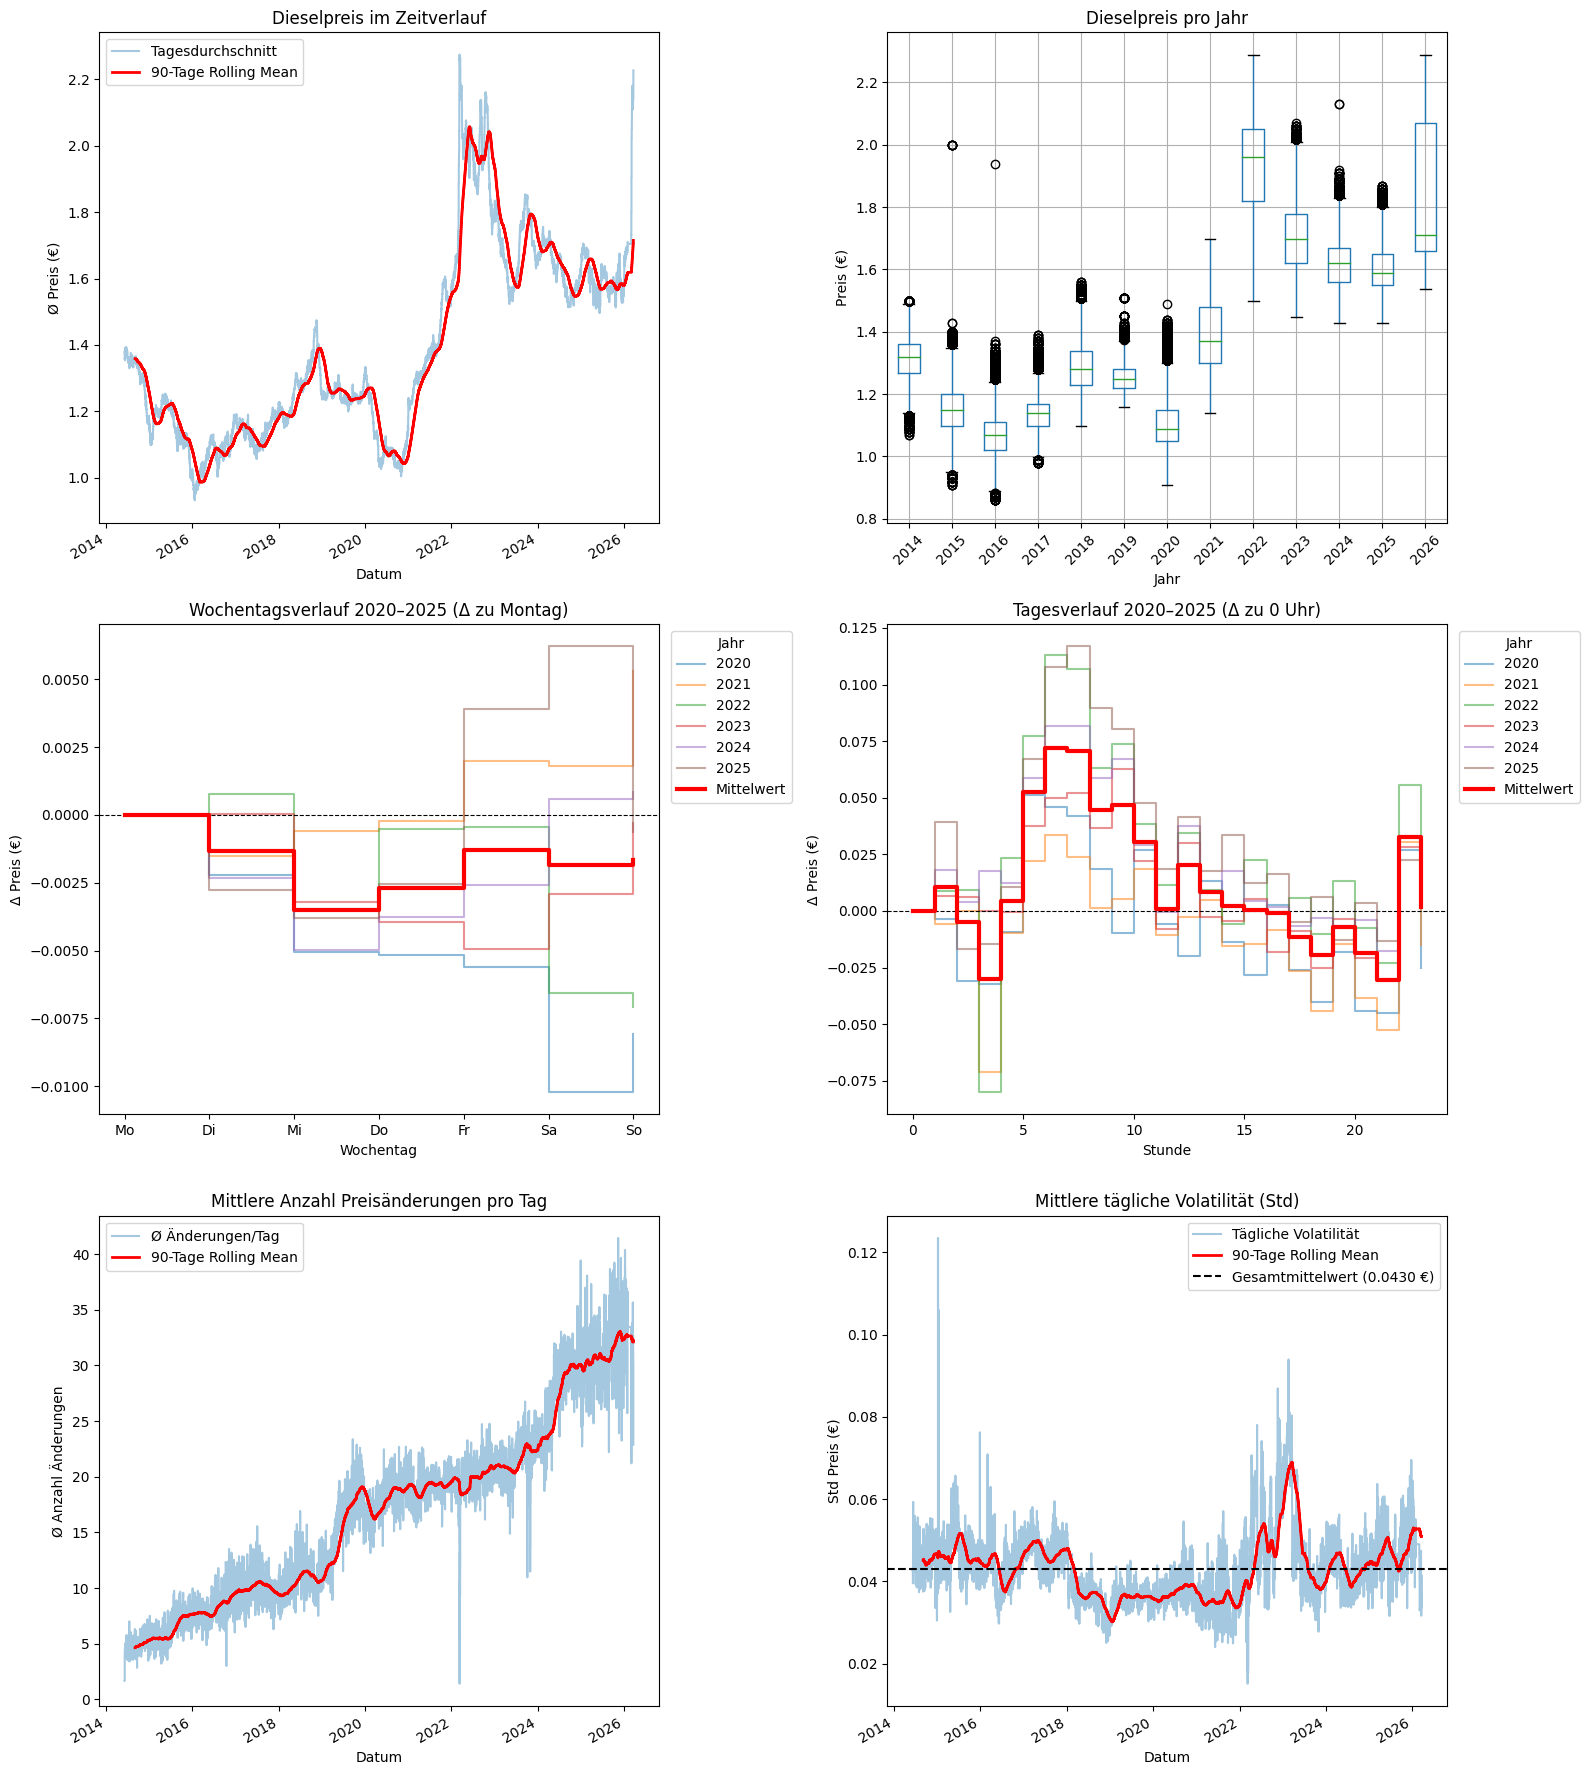

1

In [ ]:
# =========================================
# Teil 4: EDA - Zielverteilung Diesel
# =========================================
import matplotlib.pyplot as plt
import pandas as pd

# --- Hilfsspalten temporär erzeugen ---
# wochentag und stunde wurden in TEIL 4 gedroppt.
# Wir leiten sie hier frisch aus date ab — nur für die EDA,
# werden am Ende dieser Zelle wieder entfernt.
df_wide["jahr"]      = df_wide["date_day"].dt.year
df_wide["kw"]        = df_wide["date_day"].dt.isocalendar().week.astype(int)
df_wide["wochentag"] = df_wide["date"].dt.dayofweek          # 0=Mo … 6=So
df_wide["stunde"]    = df_wide["date"].dt.hour

fig, axes = plt.subplots(3, 2, figsize=(16, 18))

# --- Plot 1: Zeitverlauf mit Rolling Mean ---
tagesdurchschnitt = df_wide.groupby("date_day")["preis_diesel"].mean()
tagesdurchschnitt.plot(ax=axes[0][0], alpha=0.4, label="Tagesdurchschnitt", drawstyle="steps-post")
tagesdurchschnitt.rolling(90).mean().plot(ax=axes[0][0], color="red", linewidth=2, label="90-Tage Rolling Mean", drawstyle="steps-post")
axes[0][0].set_title("Dieselpreis im Zeitverlauf")
axes[0][0].set_xlabel("Datum")
axes[0][0].set_ylabel("Ø Preis (€)")
axes[0][0].legend()

# --- Plot 2: Boxplot pro Jahr ---
df_wide.boxplot(column="preis_diesel", by="jahr", ax=axes[0][1], rot=45)
axes[0][1].set_title("Dieselpreis pro Jahr")
axes[0][1].set_xlabel("Jahr")
axes[0][1].set_ylabel("Preis (€)")
plt.suptitle("")

# --- Plot 3: Wochentag-Verlauf 2020-2025 normalisiert + Gesamtmittelwert ---
alle_norm_wt = []
for jahr in range(2020, 2026):
    if jahr not in df_wide["jahr"].values:
        continue
    jahr_df = df_wide[df_wide["jahr"] == jahr].copy()
    tages_wt = jahr_df.groupby(["kw", "wochentag"])["preis_diesel"].mean().reset_index()
    basis = tages_wt[tages_wt["wochentag"] == 0].set_index("kw")["preis_diesel"]
    tages_wt["basis"] = tages_wt["kw"].map(basis)
    tages_wt["preis_norm"] = tages_wt["preis_diesel"] - tages_wt["basis"]
    wt_norm = tages_wt.groupby("wochentag")["preis_norm"].mean()
    wt_norm.plot(ax=axes[1][0], drawstyle="steps-post", label=str(jahr), alpha=0.5)
    alle_norm_wt.append(wt_norm)

pd.concat(alle_norm_wt, axis=1).mean(axis=1).plot(
    ax=axes[1][0], drawstyle="steps-post", color="red", linewidth=3, label="Mittelwert", zorder=5
)
axes[1][0].axhline(0, color="black", linewidth=0.8, linestyle="--")
axes[1][0].set_title("Wochentagsverlauf 2020–2025 (Δ zu Montag)")
axes[1][0].set_xlabel("Wochentag")
axes[1][0].set_ylabel("Δ Preis (€)")
axes[1][0].set_xticks(range(7))
axes[1][0].set_xticklabels(["Mo", "Di", "Mi", "Do", "Fr", "Sa", "So"])
axes[1][0].legend(title="Jahr", bbox_to_anchor=(1.01, 1), loc="upper left")

# --- Plot 4: Tagesverlauf 2020-2025 normalisiert + Gesamtmittelwert ---
alle_norm = []
for jahr in range(2020, 2026):
    if jahr not in df_wide["jahr"].values:
        continue
    jahr_df = df_wide[df_wide["jahr"] == jahr].copy()
    tages_stunden = jahr_df.groupby(["date_day", "stunde"])["preis_diesel"].mean().reset_index()
    basis = tages_stunden[tages_stunden["stunde"] == 0].set_index("date_day")["preis_diesel"]
    tages_stunden["basis"] = tages_stunden["date_day"].map(basis)
    tages_stunden["preis_norm"] = tages_stunden["preis_diesel"] - tages_stunden["basis"]
    stunden_norm = tages_stunden.groupby("stunde")["preis_norm"].mean()
    stunden_norm.plot(ax=axes[1][1], drawstyle="steps-post", label=str(jahr), alpha=0.5)
    alle_norm.append(stunden_norm)

pd.concat(alle_norm, axis=1).mean(axis=1).plot(
    ax=axes[1][1], drawstyle="steps-post", color="red", linewidth=3, label="Mittelwert", zorder=5
)
axes[1][1].axhline(0, color="black", linewidth=0.8, linestyle="--")
axes[1][1].set_title("Tagesverlauf 2020–2025 (Δ zu 0 Uhr)")
axes[1][1].set_xlabel("Stunde")
axes[1][1].set_ylabel("Δ Preis (€)")
axes[1][1].legend(title="Jahr", bbox_to_anchor=(1.01, 1), loc="upper left")

# --- Plot 5: Mittlere Anzahl Preisänderungen pro Tag ---
anzahl_aenderungen = (
    df_wide.sort_values(["station_uuid", "date"])
    .groupby(["date_day", "station_uuid"])["preis_diesel"]
    .apply(lambda x: (x.diff() != 0).sum())
    .groupby("date_day")
    .mean()
)
anzahl_aenderungen.plot(ax=axes[2][0], alpha=0.4, label="Ø Änderungen/Tag", drawstyle="steps-post")
anzahl_aenderungen.rolling(90).mean().plot(ax=axes[2][0], color="red", linewidth=2, label="90-Tage Rolling Mean", drawstyle="steps-post")
axes[2][0].set_title("Mittlere Anzahl Preisänderungen pro Tag")
axes[2][0].set_xlabel("Datum")
axes[2][0].set_ylabel("Ø Anzahl Änderungen")
axes[2][0].legend()

# --- Plot 6: Mittlere tägliche Volatilität (Std pro Tag) ---
tages_volatilitaet = df_wide.groupby("date_day")["preis_diesel"].std()
tages_volatilitaet.plot(ax=axes[2][1], alpha=0.4, label="Tägliche Volatilität", drawstyle="steps-post")
tages_volatilitaet.rolling(90).mean().plot(ax=axes[2][1], color="red", linewidth=2, label="90-Tage Rolling Mean", drawstyle="steps-post")
axes[2][1].axhline(tages_volatilitaet.mean(), color="black", linewidth=1.5, linestyle="--", label=f"Gesamtmittelwert ({tages_volatilitaet.mean():.4f} €)")
axes[2][1].set_title("Mittlere tägliche Volatilität (Std)")
axes[2][1].set_xlabel("Datum")
axes[2][1].set_ylabel("Std Preis (€)")
axes[2][1].legend()

plt.tight_layout()
plt.show()

# --- Temporäre Hilfsspalten wieder entfernen ---
df_wide.drop(columns=["jahr", "kw", "wochentag", "stunde"], errors="ignore", inplace=True)
gc.collect()
ctypes.CDLL("libc.so.6").malloc_trim(0)

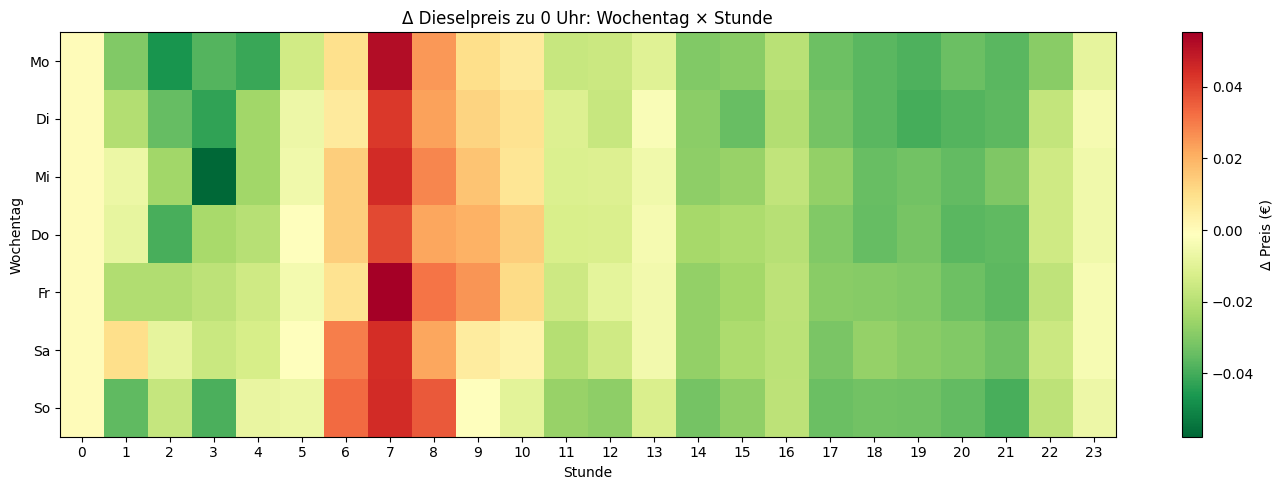

1

In [ ]:
# =========================================
# EDA - Heatmap Wochentag × Stunde (normalisiert)
# =========================================
import matplotlib.pyplot as plt

# --- Hilfsspalten temporär erzeugen ---
df_wide["wochentag"] = df_wide["date"].dt.dayofweek
df_wide["stunde"]    = df_wide["date"].dt.hour

# Pro Tag und Station: Mittelwert 0 Uhr als Basis
tages_basis = (
    df_wide[df_wide["stunde"] == 0]
    .groupby(["date_day", "station_uuid"])["preis_diesel"]
    .mean()
    .rename("basis")
)

# Basis auf alle Zeilen joinen
df_norm = df_wide.join(tages_basis, on=["date_day", "station_uuid"])

# Normalisierung: Δ zu 0 Uhr
df_norm["preis_norm"] = df_norm["preis_diesel"] - df_norm["basis"]

# Aggregieren nach Wochentag und Stunde
heatmap_data = (
    df_norm.groupby(["wochentag", "stunde"])["preis_norm"]
    .mean()
    .unstack()
)

fig, ax = plt.subplots(figsize=(14, 5))
im = ax.imshow(heatmap_data, aspect="auto", cmap="RdYlGn_r")
ax.set_title("Δ Dieselpreis zu 0 Uhr: Wochentag × Stunde")
ax.set_xlabel("Stunde")
ax.set_ylabel("Wochentag")
ax.set_xticks(range(24))
ax.set_xticklabels(range(24))
ax.set_yticks(range(7))
ax.set_yticklabels(["Mo", "Di", "Mi", "Do", "Fr", "Sa", "So"])
plt.colorbar(im, ax=ax, label="Δ Preis (€)")
plt.tight_layout()
plt.show()

# --- Aufräumen ---
del df_norm
df_wide.drop(columns=["wochentag", "stunde"], errors="ignore", inplace=True)
gc.collect()
ctypes.CDLL("libc.so.6").malloc_trim(0)

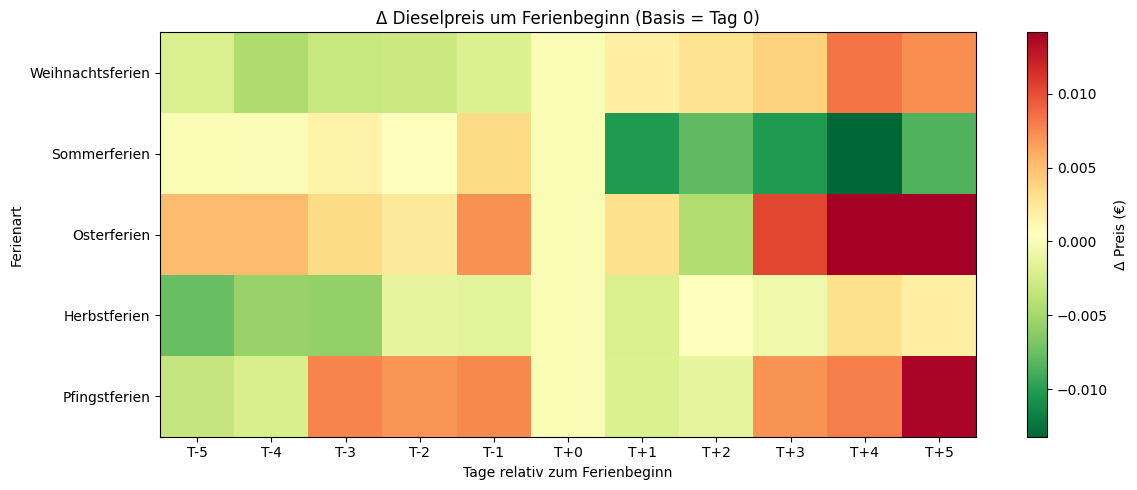

In [ ]:
# =========================================
# EDA - Heatmap Ferienbeginn ±5 Tage
# =========================================
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Nur NRW, nur Hauptferienarten
ferienarten_relevant = [
    "Weihnachtsferien", "Sommerferien", "Osterferien",
    "Herbstferien", "Pfingstferien"
]

df_schulferien = pd.read_csv("../data/schulferien.csv")
df_schulferien_nrw = df_schulferien[
    (df_schulferien["bundesland_code"] == "DE-NW") &
    (df_schulferien["name"].isin(ferienarten_relevant))
].copy()

df_schulferien_nrw["datum_start"] = pd.to_datetime(df_schulferien_nrw["datum_start"])

# Tagesdurchschnitt normalisiert (Basis = Mittelwert des Tages)
tages_mean = df_wide.groupby("date_day")["preis_diesel"].mean()

# Pro Ferienart: Δ-Preis für Tag -5 bis +5 relativ zum Ferienbeginn
fenster = range(-5, 6)
heatmap_rows = {}

for ferienart in ferienarten_relevant:
    starts = df_schulferien_nrw[df_schulferien_nrw["name"] == ferienart]["datum_start"]
    delta_werte = {t: [] for t in fenster}

    for start in starts:
        basis_preis = tages_mean.get(start, None)
        if basis_preis is None:
            continue
        for t in fenster:
            tag = start + pd.Timedelta(days=t)
            preis = tages_mean.get(tag, None)
            if preis is not None:
                delta_werte[t].append(preis - basis_preis)  # Delta zu T0

    # Mittelwert der Deltas — T0 ist immer 0 per Definition
    heatmap_rows[ferienart] = {t: np.mean(v) if v else np.nan for t, v in delta_werte.items()}

df_heatmap = pd.DataFrame(heatmap_rows).T
df_heatmap.columns = [f"T{t:+d}" for t in fenster]

fig, ax = plt.subplots(figsize=(12, 5))
im = ax.imshow(df_heatmap.values, aspect="auto", cmap="RdYlGn_r")
ax.set_title("Δ Dieselpreis um Ferienbeginn (Basis = Tag 0)")
ax.set_xlabel("Tage relativ zum Ferienbeginn")
ax.set_ylabel("Ferienart")
ax.set_xticks(range(len(df_heatmap.columns)))
ax.set_xticklabels(df_heatmap.columns)
ax.set_yticks(range(len(df_heatmap.index)))
ax.set_yticklabels(df_heatmap.index)
plt.colorbar(im, ax=ax, label="Δ Preis (€)")
plt.tight_layout()
plt.show()

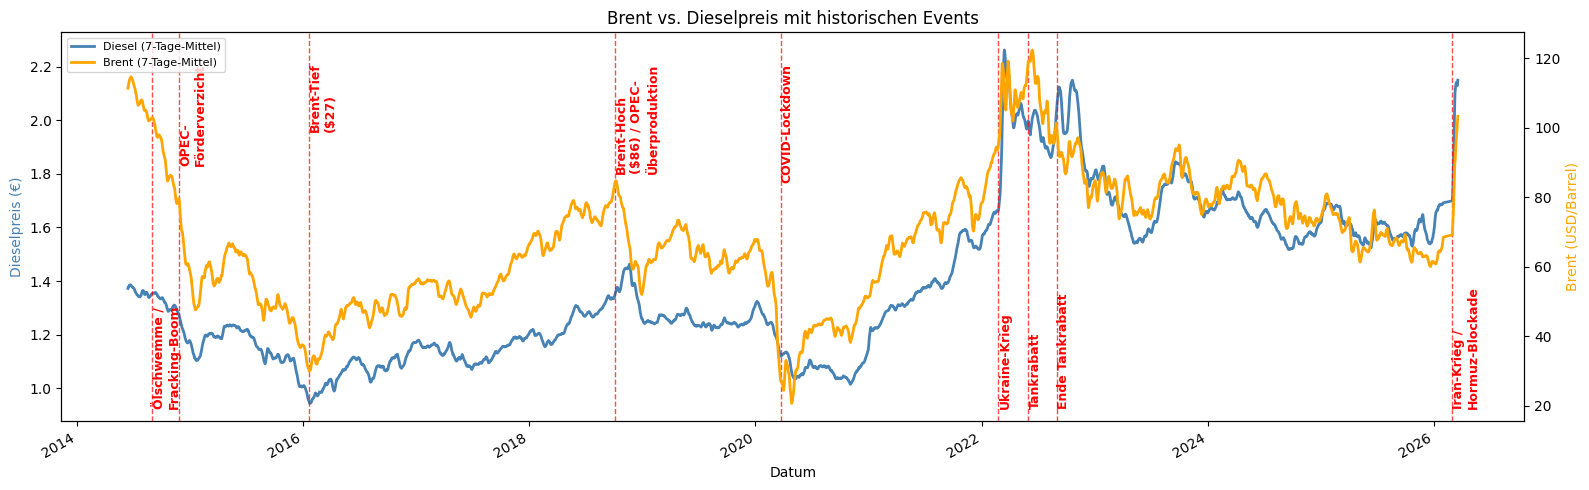


Quellen:
2014-09-01 — Ölschwemme / Fracking-Boom
  Quelle: Wikipedia: 2010s oil glut — US-Schieferölproduktion verdoppelte sich seit 2008
  URL:    https://en.wikipedia.org/wiki/2010s_oil_glut

2014-11-27 — OPEC-Förderverzicht
  Quelle: OPEC Pressemitteilung 166. Meeting, Wien — Saudi-Arabien blockiert Produktionskürzungen
  URL:    https://www.opec.org/pr-detail/84-27-nov-2014.html

2016-01-20 — Brent-Tief ($27)
  Quelle: Wikipedia: 2010s oil glut — niedrigster Brent-Preis seit 2003
  URL:    https://en.wikipedia.org/wiki/2010s_oil_glut

2018-10-03 — Brent-Hoch ($86) / OPEC-Überproduktion
  Quelle: Wikipedia: 2010s oil glut — Brent erreichte am 3. Oktober 2018 $86.29/barrel
  URL:    https://en.wikipedia.org/wiki/2010s_oil_glut

2020-03-23 — COVID-Lockdown
  Quelle: Liberty Street Economics — Nachfrageeinbruch + Saudi-Russland Ölpreiskrieg
  URL:    https://libertystreeteconomics.newyorkfed.org/2020/05/putting-the-current-oil-price-collapse-into-historical-perspective/

2022-02-24 — 

In [ ]:
# =========================================
# EDA - Externe Events und ihr Einfluss auf den Rohöl / Dieselpreis
# =========================================
import textwrap

def label_wrap(text, width=15):
    return "\n".join(textwrap.wrap(text, width=width))

events = {
    "2014-09-01": {
        "label": "Ölschwemme / Fracking-Boom",
        "va": "bottom",
        "quelle": "Wikipedia: 2010s oil glut — US-Schieferölproduktion verdoppelte sich seit 2008",
        "beleg": "https://en.wikipedia.org/wiki/2010s_oil_glut"
    },
    "2014-11-27": {
        "label": "OPEC-Förderverzicht",
        "va": "top",
        "quelle": "OPEC Pressemitteilung 166. Meeting, Wien — Saudi-Arabien blockiert Produktionskürzungen",
        "beleg": "https://www.opec.org/pr-detail/84-27-nov-2014.html"
    },
    "2016-01-20": {
        "label": "Brent-Tief ($27)",
        "va": "top",
        "quelle": "Wikipedia: 2010s oil glut — niedrigster Brent-Preis seit 2003",
        "beleg": "https://en.wikipedia.org/wiki/2010s_oil_glut"
    },
    "2018-10-03": {
        "label": "Brent-Hoch ($86) / OPEC-Überproduktion",
        "va": "top",
        "quelle": "Wikipedia: 2010s oil glut — Brent erreichte am 3. Oktober 2018 $86.29/barrel",
        "beleg": "https://en.wikipedia.org/wiki/2010s_oil_glut"
    },
    "2020-03-23": {
        "label": "COVID-Lockdown",
        "va": "top",
        "quelle": "Liberty Street Economics — Nachfrageeinbruch + Saudi-Russland Ölpreiskrieg",
        "beleg": "https://libertystreeteconomics.newyorkfed.org/2020/05/putting-the-current-oil-price-collapse-into-historical-perspective/"
    },
    "2022-02-24": {
        "label": "Ukraine-Krieg",
        "va": "bottom",
        "quelle": "Allgemein bekannt — russische Invasion, internationale Sanktionen",
        "beleg": "https://en.wikipedia.org/wiki/2022_Russian_invasion_of_Ukraine"
    },
    "2022-06-01": {
        "label": "Tankrabatt",
        "va": "bottom",
        "quelle": "Bundesregierung — temporäre Energiesteuerabsenkung Juni-August 2022",
        "beleg": "https://www.bundesfinanzministerium.de"
    },
    "2022-08-31": {
        "label": "Ende Tankrabatt",
        "va": "bottom",
        "quelle": "Bundesregierung — Tankrabatt lief am 31. August 2022 aus",
        "beleg": "https://www.bundesfinanzministerium.de"
    },
    "2026-02-28": {
        "label": "Iran-Krieg / Hormuz-Blockade",
        "va": "bottom",
        "quelle": "Al Jazeera — US-israelische Angriffe auf Iran, Brent stieg über $100",
        "beleg": "https://www.aljazeera.com/news/2026/3/10/how-will-soaring-oil-prices-caused-by-iran-war-impact-food-prices"
    },
}

# Plot
fig, ax1 = plt.subplots(figsize=(16, 5))

tagesdurchschnitt = df_wide.groupby("date_day")["preis_diesel"].mean()
tagesdurchschnitt.rolling(7).mean().plot(ax=ax1, color="steelblue", linewidth=2, label="Diesel (7-Tage-Mittel)")
ax1.set_ylabel("Dieselpreis (€)", color="steelblue")
ax1.set_xlabel("Datum")

ax2 = ax1.twinx()
# brent_lag1d wurde in TEIL 4 zu brent_t0 umbenannt
brent = df_wide.groupby("date_day")["brent_t0"].mean()
brent.rolling(7).mean().plot(ax=ax2, color="orange", linewidth=2, label="Brent (7-Tage-Mittel)")
ax2.set_ylabel("Brent (USD/Barrel)", color="orange")

for datum, info in events.items():
    ax1.axvline(pd.Timestamp(datum), color="red", linewidth=1, linestyle="--", alpha=0.7)
    y = ax1.get_ylim()[1] * 0.95 if info["va"] == "top" else ax1.get_ylim()[0] * 1.05
    ax1.text(pd.Timestamp(datum), y, label_wrap(info["label"]),
             rotation=90, fontsize=9, color="red", va=info["va"], fontweight="bold")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left", fontsize=8)
plt.title("Brent vs. Dieselpreis mit historischen Events")
plt.tight_layout()
plt.show()

# Quellenübersicht
print("\nQuellen:")
for datum, info in events.items():
    print(f"{datum} — {info['label']}")
    print(f"  Quelle: {info['quelle']}")
    print(f"  URL:    {info['beleg']}\n")

In [ ]:
# =========================================
# TEIL 5: Feature Engineering (RAM-robust)
# =========================================
# Strategie: alle Operationen in-place, nach jedem Schritt RAM freigeben,
# keine temporären Kopien erzeugen. groupby().shift() ist der RAM-Killer —
# wir ersetzen es durch sort + shift direkt auf dem sortierten DataFrame.

import gc
import ctypes
import psutil

def ram_freigeben(label=""):
    """Gibt Python-Heap und OS-Heap frei, zeigt aktuellen RAM-Verbrauch."""
    gc.collect()
    ctypes.CDLL("libc.so.6").malloc_trim(0)
    mb = psutil.Process().memory_info().rss / 1e6
    print(f"[RAM] {label}: {mb:.0f} MB")

ram_freigeben("Start TEIL 4")

# --- Schritt 1: Sortieren (Voraussetzung für korrekte Shifts) ---
# Wichtig: erst nach station_uuid, dann nach date sortieren,
# damit shift() immer innerhalb einer Tankstelle bleibt.
df_wide.sort_values(["station_uuid", "date"], inplace=True)
df_wide.reset_index(drop=True, inplace=True)
ram_freigeben("nach Sort")

# --- Schritt 2: Zielvariable — Preisänderung morgen (T+1 Delta) ---
# delta_1d = Preis morgen minus Preis heute, pro Tankstelle.
# shift(-1) schaut einen Tag voraus. Am letzten Tag jeder Station → NaN.
df_wide["delta_1d"] = (
    df_wide.groupby("station_uuid")["preis_diesel"]
    .shift(-1)
    .sub(df_wide["preis_diesel"])
)
ram_freigeben("nach delta_1d")

# --- Schritt 3: Heutige Preisänderung (T+0 Delta) ---
# delta_t0 = Preis heute minus Preis gestern, pro Tankstelle.
df_wide["delta_t0"] = (
    df_wide.groupby("station_uuid")["preis_diesel"]
    .diff()
)
ram_freigeben("nach delta_t0")

# --- Schritt 4: 7-Tage Rolling Mean des Dieselpreises ---
# roll7_t0 gibt dem Modell den mittelfristigen Preistrend.
# min_periods=1 verhindert NaNs in der ersten Woche.
df_wide["roll7_t0"] = (
    df_wide.groupby("station_uuid")["preis_diesel"]
    .transform(lambda x: x.rolling(7, min_periods=1).mean())
)
ram_freigeben("nach roll7_t0")

# --- Schritt 5: Brent heute als Feature (kein Lag nötig — bereits Tageswert) ---
# Umbenennen für Klarheit im Feature-Set.
if "brent_usd" in df_wide.columns:
    df_wide.rename(columns={"brent_usd": "brent_t0"}, inplace=True)

# --- Schritt 6: EUR/USD heute als Feature ---
if "eur_usd" in df_wide.columns:
    df_wide.rename(columns={"eur_usd": "eur_usd_t0"}, inplace=True)

# --- Schritt 7: Brent-Richtung binär (steigt morgen?) ---
# 1 = Brent heute höher als gestern, 0 = gleich oder gefallen.
# Gibt dem Modell ein einfaches Richtungssignal ohne genauen Betrag.
df_wide["brent_steigt"] = (
    df_wide["brent_t0"].diff().gt(0).astype(int)
)
ram_freigeben("nach brent_steigt")

# --- Schritt 8: Wochentag und Feiertag für T+1 ---
# Das Modell soll vorhersagen was *morgen* passiert —
# also braucht es den Wochentag von morgen, nicht von heute.
# wochentag wird hier frisch aus date abgeleitet — die Rohspalte
# wurde bereits in der EDA-Zelle gedroppt.
df_wide["wochentag_t1"] = (df_wide["date"].dt.dayofweek + 1) % 7
df_wide["ist_feiertag_t1"]    = df_wide["ist_feiertag_nrw"].shift(-1).fillna(0).astype(int)
df_wide["ist_schulferien_t1"] = df_wide["ist_schulferien_nrw"].shift(-1).fillna(0).astype(int)
ram_freigeben("nach T+1 Features")

# --- Schritt 9: Nicht benötigte Spalten droppen ---
# Alles was weder Feature noch Zielvariable noch Identifier ist, fliegt raus.
drop_now = [
    # Rohspalten die wir durch Features ersetzt haben
    "temp_avg", "temp_min", "temp_max",
    "niederschlag_mm", "sonnenstunden",
    "ist_schulferien_nrw", "ist_feiertag_nrw",
    "wochentag",
    # Steuern und Events — zu statisch, kein Vorhersagewert für T+1 Delta
    "co2_preis_eur_t", "energiesteuer_diesel", "energiesteuer_benzin",
    "ist_tankrabatt", "ist_niedrigwasser", "ist_lockdown",
    # Zeitfelder die wir nicht mehr brauchen
    "jahr", "quartal", "monat", "tag", "stunde", "ist_wochenende",
    # Vorberechnete Lags aus TEIL 3 — durch unsere eigenen Features ersetzt
    "preis_diesel_lag1", "preis_diesel_lag7d", "preis_diesel_lag30d",
    "preis_diesel_delta1", "preis_diesel_delta7d",
    "preis_diesel_roll7", "preis_diesel_interpol",
    "brent_lag3d",
    # Duplikate aus Merge (_x / _y Suffixe falls vorhanden)
    "brent_usd_x", "brent_usd_y", "eur_usd_x", "eur_usd_y",
]
drop_now = [c for c in drop_now if c in df_wide.columns]
df_wide.drop(columns=drop_now, inplace=True)
ram_freigeben("nach Drop")

# --- Schritt 10: Zeilen mit NaN in Zielvariable entfernen ---
# Die letzte Beobachtung jeder Tankstelle hat kein delta_1d (shift(-1) → NaN).
# Diese Zeilen können nicht trainiert werden.
zeilen_vorher = len(df_wide)
df_wide.dropna(subset=["delta_1d"], inplace=True)
df_wide.reset_index(drop=True, inplace=True)
print(f"Zeilen entfernt (kein delta_1d): {zeilen_vorher - len(df_wide):,}")
ram_freigeben("nach dropna")

# --- Abschluss-Check ---
print(f"\ndf_wide final: {df_wide.shape}")
print(f"Spalten: {df_wide.columns.tolist()}")
print(f"\nErwartete Spalten für ML:")
print(f"  Identifier:    date, station_uuid, date_day")
print(f"  Zielvariable:  delta_1d")
print(f"  Features:      preis_diesel, delta_t0, roll7_t0, brent_t0, eur_usd_t0,")
print(f"                 brent_steigt, wochentag_t1, ist_feiertag_t1, ist_schulferien_t1")

[RAM] Start TEIL 4: 3887 MB
[RAM] nach Sort: 3887 MB
[RAM] nach delta_1d: 3887 MB
[RAM] nach delta_t0: 3887 MB
[RAM] nach roll7_t0: 3887 MB
[RAM] nach brent_steigt: 3887 MB


KeyError: 'ist_feiertag_nrw'

In [ ]:
pd.read_parquet("../data/ml/ml_master_dataset.parquet", columns=None).columns.tolist()

['date',
 'station_uuid',
 'kraftstoff',
 'preis',
 'jahr',
 'quartal',
 'monat',
 'tag',
 'stunde',
 'wochentag',
 'ist_wochenende',
 'date_day',
 'temp_avg',
 'temp_min',
 'temp_max',
 'niederschlag_mm',
 'sonnenstunden',
 'brent_usd',
 'eur_usd',
 'co2_preis_eur_t',
 'energiesteuer_benzin',
 'energiesteuer_diesel',
 'ist_tankrabatt',
 'ist_lockdown',
 'ist_niedrigwasser',
 'ist_schulferien_nrw',
 'ist_feiertag_nrw']

In [ ]:
# Lücken prüfen
print(df_wide[["delta_1d", "delta_t0", "roll7_t0", "brent_t0", "eur_usd_t0"]].isnull().sum())
print(f"\nGesamt NaN: {df_wide.isnull().sum().sum()}")

delta_1d        0
delta_t0      547
roll7_t0        0
brent_t0        0
eur_usd_t0      0
dtype: int64

Gesamt NaN: 547


In [ ]:
station = "005056ba-7cb6-1ed2-bceb-88651ca7cd30"
print(
    df_wide[df_wide["station_uuid"] == station]
    .sort_values("date")[["date", "preis_diesel", "delta_t0"]]
    .iloc[42390:42430]
)


                     date  preis_diesel  delta_t0
42390 2022-03-08 13:26:01         2.119     -0.01
42391 2022-03-08 15:36:01         2.159      0.04
42392 2022-03-08 16:26:01         2.119     -0.04
42393 2022-03-08 17:36:01         2.139      0.02
42394 2022-03-08 19:26:01         2.169      0.03
42395 2022-03-08 20:01:01         2.169      0.00
42396 2022-03-08 20:51:01         2.119     -0.05
42397 2022-03-08 23:21:01         2.179      0.06
42398 2022-03-09 07:26:01         2.219       NaN
42399 2022-03-09 08:16:01         2.209     -0.01
42400 2022-03-09 08:36:01         2.209      0.00
42401 2022-03-09 09:36:01         2.259      0.05
42402 2022-03-09 10:46:01         2.259      0.00
42403 2022-03-09 10:56:01         2.219     -0.04
42404 2022-03-09 12:36:01         2.259      0.04
42405 2022-03-09 13:16:01         2.249     -0.01
42406 2022-03-09 13:21:01         2.249      0.00
42407 2022-03-09 15:36:01         2.289      0.04
42408 2022-03-09 18:16:01         2.249       NaN


## EDA - Korrelationen

In [ ]:
station = "005056ba-7cb6-1ed2-bceb-88651ca7cd30"
duplikate = df_wide[df_wide["station_uuid"] == station].duplicated(subset=["date"], keep=False)
print(f"Doppelte Timestamps: {duplikate.sum()}")
print(df_wide[df_wide["station_uuid"] == station][duplikate][["date", "preis_diesel", "delta_t0"]].head(10))

Doppelte Timestamps: 590
                    date  preis_diesel  delta_t0
5175 2016-04-27 14:14:01      1.019000 -0.020000
5176 2016-04-27 14:14:01      1.029000  0.010000
9840 2017-07-01 08:03:07      1.099000 -0.010000
9841 2017-07-01 08:03:07      1.089000 -0.010000
9842 2017-07-01 09:53:05      1.062333 -0.026667
9843 2017-07-01 09:53:05      1.069000  0.006667
9844 2017-07-01 11:47:06      1.055667 -0.013333
9845 2017-07-01 11:47:06      1.049000 -0.006667
9847 2017-07-01 13:27:06      1.069000 -0.010000
9848 2017-07-01 13:27:06      1.059000 -0.010000


## Beobachtungen aus der Korrelationsanalyse

### Starke positive Korrelationen mit `preis_diesel`
- `preis_diesel_lag1`, `lag7d`, `lag30d`, `roll7` (~0.99) — eigene Preisverzögerungen (stärkste Features)
- `brent_lag3d` (~0.84) — Rohölpreis mit 3 Tagen Verzögerung
- `co2_preis_eur_t` (~0.70) — CO2-Zertifikatspreise
- `jahr` (~0.69) — langfristiger Preistrend
- `ist_niedrigwasser` (~0.29) — Rhein-Niedrigwasser (lokaler Lieferengpass)
- `ist_tankrabatt` (~0.27) — Tankrabatt-Periode 2022

### Negative Korrelationen
- `eur_usd_lag1d` (~-0.42) — starker Euro = billiges Öl für Europa
- `energiesteuer_diesel` (~-0.30) — Zeiteffekt, nicht kausal
- `ist_lockdown` (~-0.16) — Nachfrageeinbruch COVID

### Kein Signal → entfernt
- alle `brand_*` Spalten
- Geodaten (`latitude`, `longitude`, `distanz_km`)
- Wetter außer `temp_avg` (`temp_min`, `temp_max`, `niederschlag_mm`, `sonnenstunden`)
- Zeitfeatures (`wochentag`, `tag`, `stunde`, `monat`, `quartal`)
- Kalender (`ist_feiertag_nrw`, `ist_wochenende`, Vorabend-Features)

In [ ]:
# =========================================
# TEIL 6: Feature Selection
# =========================================

spalten_rauswerfen = [
    # Multikollinearität
    "preis_diesel_interpol",
    "brent_usd", "brent_lag1d",       # brent_lag3d behalten
    "eur_usd",                          # eur_usd_lag1d behalten
    "energiesteuer_benzin",             # energiesteuer_diesel behalten
    "preis_diesel_roll30",              # roll7 behalten
    # Geodaten — kein Signal
    "latitude", "longitude", "distanz_km",
    # Wetter — redundant
    "temp_min", "temp_max", "temp_lag1d",
    # Zeit — kein Signal
    "wochentag", "tag", "stunde", "monat", "quartal",
    # Kalender — kein Signal
    "ist_feiertag_nrw", "ist_wochenende",
    "tag_vor_feiertag", "tag_nach_feiertag", "tag_vor_schulferien",
    # Wetter — kein Signal
    "niederschlag_mm", "sonnenstunden",
    # Brand — kein Signal
    "brand_ARAL", "brand_AVEX", "brand_ESSO", "brand_JET",
    "brand_Markant", "brand_REWE", "brand_SB", "brand_STAR",
    "brand_Shell", "brand_Autohof Frechen (Mundorf Tank)",
    "brand_Globus SB Warenhaus", "brand_Tankstelle Lietsch",
    "brand_Westfalen Tankstelle",
]

# Nur vorhandene Spalten droppen
spalten_rauswerfen = [c for c in spalten_rauswerfen if c in df_wide.columns]
df_wide = df_wide.drop(columns=spalten_rauswerfen)

ram_freigeben()

print(df_wide.shape)
print(df_wide.columns.tolist())

(2437958, 21)
['date', 'station_uuid', 'jahr', 'date_day', 'temp_avg', 'co2_preis_eur_t', 'energiesteuer_diesel', 'ist_tankrabatt', 'ist_lockdown', 'ist_niedrigwasser', 'ist_schulferien_nrw', 'preis_diesel', 'post_code', 'preis_diesel_lag1', 'preis_diesel_lag7d', 'preis_diesel_lag30d', 'preis_diesel_delta1', 'preis_diesel_delta7d', 'brent_lag3d', 'eur_usd_lag1d', 'preis_diesel_roll7']


In [ ]:
# =========================================
# TEIL 7: Finales Dataset speichern
# =========================================

df_wide.to_parquet("../data/ml/ml_diesel_final.parquet", index=False)
print(f"Gespeichert: {df_wide.shape}")
print(df_wide.columns.tolist())

Gespeichert: (2437958, 21)
['date', 'station_uuid', 'jahr', 'date_day', 'temp_avg', 'co2_preis_eur_t', 'energiesteuer_diesel', 'ist_tankrabatt', 'ist_lockdown', 'ist_niedrigwasser', 'ist_schulferien_nrw', 'preis_diesel', 'post_code', 'preis_diesel_lag1', 'preis_diesel_lag7d', 'preis_diesel_lag30d', 'preis_diesel_delta1', 'preis_diesel_delta7d', 'brent_lag3d', 'eur_usd_lag1d', 'preis_diesel_roll7']
